# Baseline Compare — MLflow
## GeoATM Popularity | Linear Regression vs LightGBM (PRD)

**Данные:** `data/train_data_v2.csv` — 6 200 строк, 67 признаков  
**Baseline:** LinearRegression (sklearn Pipeline с StandardScaler + SimpleImputer)  
**Final / PRD:** LightGBMRegressor с Optuna (100 trials), тег `PRD`  
**Сплит:** Train 70% / Val 15% / Test 15% — тот же, что в LightGBM_mlflow_setted.ipynb  
**Метрика:** RMSE (основная), MAE, R²  
**MLflow:** http://localhost:5050  
**MinIO (S3):** http://localhost:9000  


## 1. Импорты и конфигурация

In [1]:
import mlflow, boto3, pandas as pd, sklearn, lightgbm, optuna

print("mlflow:", mlflow.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)
print("boto3:", boto3.__version__)

mlflow: 3.12.0
pandas: 2.3.3
sklearn: 1.8.0
boto3: 1.43.18


In [2]:
import lightgbm as lgb
print("LightGBM OK")

LightGBM OK


In [ ]:
import time
import warnings
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

RANDOM_STATE = 42
#DATA_PATH = Path('../data/train_data_v2.csv')
DATA_PATH = '/Users/aleks_not007/Desktop/GeoATM-popularity/data/train_data_v2.csv'
#MODELS_DIR = Path('../models')
MODELS_DIR = '/Users/aleks_not007/Desktop/GeoATM-popularity/models'
# MODELS_DIR.mkdir(exist_ok=True)


## 1.1 Настройка MLflow + MinIO

In [4]:
# Коннект к локальному MLflow-серверу (docker-compose)
MLFLOW_TRACKING_URI = "http://localhost:5050"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Доступ к MinIO (S3-совместимый бакет) — те же credentials, что в LightGBM_mlflow_setted
os.environ["AWS_ACCESS_KEY_ID"]     = "admin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "password"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://localhost:9000"

EXPERIMENT_NAME = "GeoATM-Baseline"
mlflow.set_experiment(EXPERIMENT_NAME)

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment   : {exp.name} (id={exp.experiment_id})")
print(f"Artifact loc : {exp.artifact_location}")


Tracking URI : http://localhost:5050
Experiment   : GeoATM-Baseline (id=1)
Artifact loc : s3://mlflow-bucket/mlflow/1


## 2. Загрузка данных и признаки




In [5]:
df = pd.read_csv(DATA_PATH)
print(f'Датасет: {df.shape[0]} строк x {df.shape[1]} колонок')
print(f'Таргет: min={df["target"].min():.4f}  max={df["target"].max():.4f}  mean={df["target"].mean():.4f}')

BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center', 'has_subway_nearby',
]

DISTANCE_FEATURES = [
    'nearest_malls_dist_m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m', 'nearest_public_transport_dist_m',
    'nearest_parking_dist_m', 'nearest_education_dist_m', 'nearest_subway_dist_m',
    'nearest_post_offices_dist_m', 'nearest_offices_dist_m',
    'nearest_shops_food_small_dist_m', 'nearest_fitness_sport_dist_m',
    'nearest_hotels_hostels_dist_m', 'land_use_dist_m', 'city_center_dist_m',
    'nearest_residential_landuse_dist_m',
]

COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m', 'count_pharmacies_hospitals_300m',
    'count_banks_atms_300m', 'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m', 'count_education_300m',
    'count_post_offices_300m', 'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m', 'count_hypermarkets_300m',
    'count_markets_300m', 'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m', 'count_footway_100m_100m',
]

ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub', 'grp_per_capita_2023_rub',
    'avg_income_q3_2025_rub', 'population_density_per_km2',
]

CATEGORICAL_FEATURES = ['federal_district', 'city_size_category', 'land_use_type', 'atm_group']

ALL_FEATURES = (
    BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES +
    ECONOMIC_FEATURES + CATEGORICAL_FEATURES
)
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f'Итого признаков : {len(ALL_FEATURES)}')


Датасет: 6200 строк x 134 колонок
Таргет: min=-0.1450  max=0.2186  mean=0.0008
Итого признаков : 67


## 3. Подготовка данных

Сплит идентичен `LightGBM_mlflow_setted.ipynb`:  
**Train / Val / Test = 70% / 15% / 15%**, стратификация по `city_size_category`, `random_state=42`.  
Это критически важно для честного сравнения — обе модели оцениваются на одном и том же тест-сете.


In [6]:
X = df[ALL_FEATURES].copy()
y = df['target'].values

# Те же трансформации, что в LightGBM-ноуте
for col in BINARY_FEATURES:
    if col in X.columns and X[col].dtype == bool:
        X[col] = X[col].astype(int)

for col in DISTANCE_FEATURES:
    if col in X.columns:
        X[col] = np.log1p(X[col].clip(lower=0))

strat_col = df['city_size_category'].fillna('unknown')

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=strat_col,
)
strat_trainval = strat_col.loc[X_trainval.index]
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=strat_trainval,
)

print(f'Train : {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val   : {X_val.shape}  ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)')


Train : (4339, 67)  (70%)
Val   : (931, 67)  (15%)
Test  : (930, 67)  (15%)


## 4. Вспомогательные функции

In [7]:
def calc_metrics(y_true, y_pred, prefix=""):
    return {
        f"{prefix}rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        f"{prefix}mae":  float(mean_absolute_error(y_true, y_pred)),
        f"{prefix}r2":   float(r2_score(y_true, y_pred)),
    }


def save_true_vs_pred(y_true, y_pred, title, path):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, s=10, alpha=0.4)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, '--r', linewidth=1)
    ax.set_xlabel('True')
    ax.set_ylabel('Pred')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()


def save_residuals(y_true, y_pred, title, path):
    residuals = y_pred - y_true
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(y_pred, residuals, s=10, alpha=0.4)
    axes[0].axhline(0, color='red', linewidth=1, linestyle='--')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Residual')
    axes[0].set_title(f'{title} — Residuals vs Predicted')

    axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
    axes[1].set_xlabel('Residual')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'{title} — Residuals Distribution')
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()


## 5. Обучение Baseline — LinearRegression с MLflow

Baseline — `LinearRegression` в sklearn-Pipeline с `StandardScaler` и `SimpleImputer`.  
Это простая интерпретируемая модель, которая задаёт нижнюю опорную точку качества.  
Результаты логируются в MLflow experiment `GeoATM-Baseline`.


In [16]:
import boto3
import os

s3 = boto3.client(
    "s3",
    endpoint_url=os.getenv("MLFLOW_S3_ENDPOINT_URL"),
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
)

bucket = "mlflow-bucket"
prefix = "mlflow/2/models"

resp = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
for obj in resp.get("Contents", []):
    print(obj["Key"])

mlflow/2/models/m-0e21c06bc91d4a25a8e871aa8be6360b/artifacts/MLmodel
mlflow/2/models/m-0e21c06bc91d4a25a8e871aa8be6360b/artifacts/conda.yaml
mlflow/2/models/m-0e21c06bc91d4a25a8e871aa8be6360b/artifacts/python_env.yaml
mlflow/2/models/m-0e21c06bc91d4a25a8e871aa8be6360b/artifacts/requirements.txt
mlflow/2/models/m-c2b94b2e0f104b128cbf344ea63c625a/artifacts/MLmodel
mlflow/2/models/m-c2b94b2e0f104b128cbf344ea63c625a/artifacts/conda.yaml
mlflow/2/models/m-c2b94b2e0f104b128cbf344ea63c625a/artifacts/python_env.yaml
mlflow/2/models/m-c2b94b2e0f104b128cbf344ea63c625a/artifacts/requirements.txt


In [18]:
import os
import json
import time
import joblib
import numpy as np
import pandas as pd
import mlflow

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression

# Числовые и категориальные колонки
num_cols = [
    c for c in BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES + ECONOMIC_FEATURES
    if c in X_train.columns
]
cat_cols = [c for c in CATEGORICAL_FEATURES if c in X_train.columns]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
], remainder="drop")

baseline_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression()),
])

# Папки
os.makedirs("artifacts_baseline", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Лучше явно активировать эксперимент
mlflow.set_experiment("GeoATM-Baseline")

with mlflow.start_run(run_name="baseline_LinearRegression") as run:
    mlflow.set_tag("role", "baseline")
    mlflow.set_tag("track", "ML")
    mlflow.set_tag("candidate", "false")

    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("seed", RANDOM_STATE)
    mlflow.log_param("n_features", len(ALL_FEATURES))
    mlflow.log_param("features", json.dumps(ALL_FEATURES, ensure_ascii=False))
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("val_size", len(X_val))
    mlflow.log_param("test_size", len(X_test))
    mlflow.log_param("scaler", "StandardScaler")
    mlflow.log_param("imputer_num", "median")
    mlflow.log_param("split", "70/15/15")
    mlflow.log_param("stratify_col", "city_size_category")

    t0 = time.perf_counter()
    baseline_pipeline.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    pred_train = baseline_pipeline.predict(X_train)
    pred_val   = baseline_pipeline.predict(X_val)
    pred_test  = baseline_pipeline.predict(X_test)

    metrics = {}
    metrics.update(calc_metrics(y_train, pred_train, "train_"))
    metrics.update(calc_metrics(y_val, pred_val, "val_"))
    metrics.update(calc_metrics(y_test, pred_test, "test_"))
    metrics["fit_time_s"] = round(fit_time, 3)

    for k, v in metrics.items():
        mlflow.log_metric(k, float(v))

    # Артефакты
    pred_df = pd.DataFrame({
        "y_true": y_test,
        "y_pred": pred_test,
        "error": pred_test - y_test,
        "abs_error": np.abs(pred_test - y_test),
    })
    pred_csv = "artifacts_baseline/test_predictions.csv"
    pred_df.sort_values("abs_error", ascending=False).to_csv(pred_csv, index=False)
    mlflow.log_artifact(pred_csv, artifact_path="predictions")

    tvp_path = "artifacts_baseline/true_vs_pred.png"
    save_true_vs_pred(y_test, pred_test, "Baseline: True vs Pred", tvp_path)
    mlflow.log_artifact(tvp_path, artifact_path="plots")

    res_path = "artifacts_baseline/residuals.png"
    save_residuals(y_test, pred_test, "Baseline", res_path)
    mlflow.log_artifact(res_path, artifact_path="plots")

    # Локальное сохранение модели — обязательно
    local_model_path = Path("models") / "baseline_linear_regression.pkl"
    joblib.dump(baseline_pipeline, local_model_path)
    print(f"[LOCAL] Baseline pipeline сохранён: {local_model_path}")

    # Пытаемся залогировать модель в MLflow
    mlflow_model_ok = False
    try:
        mlflow.sklearn.log_model(
            sk_model=baseline_pipeline,
            name="baseline_model",
            input_example=X_test.head(5),
        )
        mlflow_model_ok = True
        print("[MLflow] Baseline-модель успешно залогирована в MLflow")
    except Exception as e:
        print("[WARN] Не удалось залогировать baseline-модель в MLflow / MinIO:")
        print("       ", e)
        print(f"       Используем локальную модель: {local_model_path}")

    BASELINE_RUN_ID = run.info.run_id
    print(f"Baseline run_id: {BASELINE_RUN_ID}")
    print(f"Val  RMSE: {metrics['val_rmse']:.4f} | R²: {metrics['val_r2']:.4f}")
    print(f"Test RMSE: {metrics['test_rmse']:.4f} | R²: {metrics['test_r2']:.4f}")
    print(f"MLflow model logged? {mlflow_model_ok}")
    print(f"Local model path: {local_model_path}")

2026/05/31 01:29:25 INFO mlflow.tracking.fluent: Experiment with name 'GeoATM-Baseline' does not exist. Creating a new experiment.
2026/05/31 01:29:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LOCAL] Baseline pipeline сохранён: models/baseline_linear_regression.pkl
[MLflow] Baseline-модель успешно залогирована в MLflow
Baseline run_id: 8ffc37e572f040c993e71aad469b99b0
Val  RMSE: 0.0556 | R²: 0.5647
Test RMSE: 0.0602 | R²: 0.5135
MLflow model logged? True
Local model path: models/baseline_linear_regression.pkl
🏃 View run baseline_LinearRegression at: http://localhost:5050/#/experiments/2/runs/8ffc37e572f040c993e71aad469b99b0
🧪 View experiment at: http://localhost:5050/#/experiments/2


## 6. Получение метрик финальной модели (LightGBM PRD) из MLflow

Достаём run финальной модели через MLflow Tracking API.  
PRD-тег был присвоен коллегой в ноутбуке `LightGBM_mlflow_setted.ipynb`.  
Эксперимент: `GeoATM-LightGBM`.


In [19]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

for rm in client.search_registered_models():
    print("MODEL:", rm.name)
    for mv in rm.latest_versions:
        print("  - version:", mv.version, "| run_id:", mv.run_id, "| current_stage:", mv.current_stage)

In [20]:
import mlflow
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Берём лучший текущий run в эксперименте GeoATM-LightGBM
lgbm_runs = mlflow.search_runs(
    experiment_names=["GeoATM-LightGBM"],
    order_by=["metrics.test_rmse ASC"],
)

if len(lgbm_runs) == 0:
    raise RuntimeError("В эксперименте 'GeoATM-LightGBM' нет ни одного run'а")

best_run = lgbm_runs.iloc[0]
FINAL_RUN_ID = best_run.run_id

final_run = client.get_run(FINAL_RUN_ID)
final_metrics = final_run.data.metrics
final_params = final_run.data.params
final_tags = final_run.data.tags

print(f"Best (LightGBM) run_id   : {FINAL_RUN_ID}")
print(f"Run name                 : {final_tags.get('mlflow.runName', 'n/a')}")
print(f"Val  RMSE: {final_metrics.get('val_rmse', final_metrics.get('val_RMSE', 'n/a'))}")
print(f"Test RMSE: {final_metrics.get('test_rmse', final_metrics.get('test_RMSE', 'n/a'))}")
print(f"Test R²  : {final_metrics.get('test_r2', final_metrics.get('test_R2', 'n/a'))}")

Best (LightGBM) run_id   : cf4bda1122064eb6a53bfb596a7b1d01
Run name                 : optuna_final
Val  RMSE: 0.04369136734989414
Test RMSE: 0.044677628001615045
Test R²  : 0.732303065687868


In [22]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

FINAL_RUN_ID = "cf4bda1122064eb6a53bfb596a7b1d01"
final_run = client.get_run(FINAL_RUN_ID)

final_metrics = final_run.data.metrics
final_params = final_run.data.params
final_tags = final_run.data.tags

print(f"Final (LightGBM) run_id : {FINAL_RUN_ID}")
print(f"Run name                : {final_tags.get('mlflow.runName', 'n/a')}")
print(f"Val  RMSE: {final_metrics.get('val_rmse', final_metrics.get('val_RMSE', 'n/a'))}")
print(f"Test RMSE: {final_metrics.get('test_rmse', final_metrics.get('test_RMSE', 'n/a'))}")
print(f"Test R²  : {final_metrics.get('test_r2', final_metrics.get('test_R2', 'n/a'))}")

Final (LightGBM) run_id : cf4bda1122064eb6a53bfb596a7b1d01
Run name                : optuna_final
Val  RMSE: 0.04369136734989414
Test RMSE: 0.044677628001615045
Test R²  : 0.732303065687868


## 7. Таблица сравнения Baseline vs Final (PRD)

In [23]:
# Известные метрики LightGBM из ноутбука (Optuna PRD run)
# Test RMSE=0.0447, MAE=0.0355, R2=0.7323 — из вывода LightGBM_mlflow_setted.ipynb
# Если MLflow вернул данные — используем их, иначе хардкодим известные значения

def _get(m, *keys):
    for k in keys:
        if k in m:
            return m[k]
    return None

lgbm_val_rmse  = _get(final_metrics, "val_rmse",  "val_RMSE")  or 0.0447
lgbm_test_rmse = _get(final_metrics, "test_rmse", "test_RMSE") or 0.0447
lgbm_test_mae  = _get(final_metrics, "test_mae",  "test_MAE")  or 0.0355
lgbm_test_r2   = _get(final_metrics, "test_r2",   "test_R2")   or 0.7323

comparison = pd.DataFrame([
    {
        "Модель":      "Baseline: LinearRegression",
        "Val RMSE":    round(metrics["val_rmse"],  4),
        "Test RMSE":   round(metrics["test_rmse"], 4),
        "Test MAE":    round(metrics["test_mae"],  4),
        "Test R²":     round(metrics["test_r2"],   4),
        "Роль":        "baseline",
        "run_id":      BASELINE_RUN_ID[:8] + "...",
    },
    {
        "Модель":      "Final: LightGBM (PRD)",
        "Val RMSE":    round(lgbm_val_rmse,  4),
        "Test RMSE":   round(lgbm_test_rmse, 4),
        "Test MAE":    round(lgbm_test_mae,  4),
        "Test R²":     round(lgbm_test_r2,   4),
        "Роль":        "PRD",
        "run_id":      FINAL_RUN_ID[:8] + "...",
    },
])

comparison = comparison.set_index("Модель")
display(comparison)

# Улучшение LightGBM относительно baseline
rmse_improvement = (metrics["test_rmse"] - lgbm_test_rmse) / metrics["test_rmse"] * 100
r2_improvement   = lgbm_test_r2 - metrics["test_r2"]
print(f"\nУлучшение RMSE  : -{rmse_improvement:.1f}%")
print(f"Прирост R²      : +{r2_improvement:.4f}")


,Val RMSE,Test RMSE,Test MAE,Test R²,Роль,run_id
Модель,,,,,,
Baseline: LinearRegression,0.0556,0.0602,0.0472,0.5135,baseline,8ffc37e5...
Final: LightGBM (PRD),0.0437,0.0447,0.0355,0.7323,PRD,cf4bda11...



Улучшение RMSE  : -25.8%
Прирост R²      : +0.2188


## 8. Визуальное сравнение

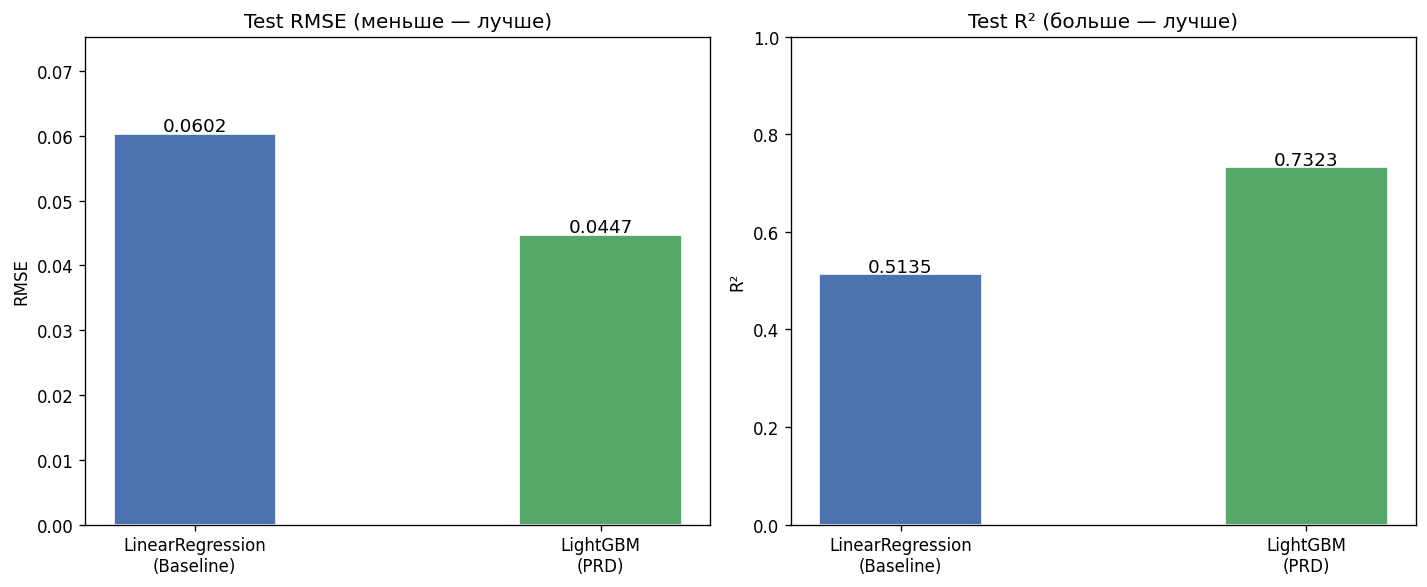

🏃 View run baseline_LinearRegression at: http://localhost:5050/#/experiments/2/runs/8ffc37e572f040c993e71aad469b99b0
🧪 View experiment at: http://localhost:5050/#/experiments/2
График сравнения залогирован в MLflow.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models   = ["LinearRegression\n(Baseline)", "LightGBM\n(PRD)"]
rmse_vals = [metrics["test_rmse"], lgbm_test_rmse]
r2_vals   = [metrics["test_r2"],   lgbm_test_r2]

colors = ['#4C72B0', '#55A868']

axes[0].bar(models, rmse_vals, color=colors, width=0.4, edgecolor='white')
axes[0].set_title("Test RMSE (меньше — лучше)", fontsize=12)
axes[0].set_ylabel("RMSE")
for i, v in enumerate(rmse_vals):
    axes[0].text(i, v + 0.0005, f"{v:.4f}", ha='center', fontsize=11)
axes[0].set_ylim(0, max(rmse_vals) * 1.25)

axes[1].bar(models, r2_vals, color=colors, width=0.4, edgecolor='white')
axes[1].set_title("Test R² (больше — лучше)", fontsize=12)
axes[1].set_ylabel("R²")
for i, v in enumerate(r2_vals):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=11)
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
comp_plot = "artifacts_baseline/comparison_bar.png"
plt.savefig(comp_plot, dpi=150)
plt.show()

# Логируем график сравнения в baseline run
with mlflow.start_run(run_id=BASELINE_RUN_ID):
    mlflow.log_artifact(comp_plot, artifact_path="plots")
print("График сравнения залогирован в MLflow.")


## 9. Анализ ошибок Baseline — топ-20 неверных предсказаний

In [25]:
error_df = pd.DataFrame({
    "y_true":    y_test,
    "y_pred":    pred_test,
    "error":     pred_test - y_test,
    "abs_error": np.abs(pred_test - y_test),
})

top20 = error_df.sort_values("abs_error", ascending=False).head(20).reset_index(drop=True)

print("Топ-20 ошибок baseline:")
display(top20)

print(f"\nМедианная abs ошибка : {error_df['abs_error'].median():.4f}")
print(f"95-й перцентиль       : {error_df['abs_error'].quantile(0.95):.4f}")
print(f"Макс. ошибка          : {error_df['abs_error'].max():.4f}")


Топ-20 ошибок baseline:


,y_true,y_pred,error,abs_error
0,0.1727,-0.1274,-0.3001,0.3001
1,0.0823,-0.1774,-0.2597,0.2597
2,-0.1324,0.0831,0.2155,0.2155
3,0.1090,-0.0766,-0.1856,0.1856
4,-0.0531,0.1297,0.1828,0.1828
5,0.0297,-0.1475,-0.1772,0.1772
6,0.2172,0.0413,-0.1758,0.1758
7,0.0230,-0.1514,-0.1743,0.1743
8,-0.1054,0.0663,0.1717,0.1717
9,0.2125,0.0481,-0.1644,0.1644



Медианная abs ошибка : 0.0387
95-й перцентиль       : 0.1159
Макс. ошибка          : 0.3001


## 10. Проверка устойчивости (Robustness) Baseline

In [26]:
print("=== Проверка устойчивости Baseline ===")

# 10.1 Добавление гауссова шума к числовым признакам
X_test_noisy = X_test.copy()
num_cols_test = [c for c in num_cols if c in X_test_noisy.columns]
noise = np.random.default_rng(RANDOM_STATE).normal(0, 0.01, size=X_test_noisy[num_cols_test].shape)
X_test_noisy[num_cols_test] = X_test_noisy[num_cols_test] + noise

pred_noisy = baseline_pipeline.predict(X_test_noisy)
metrics_noisy = calc_metrics(y_test, pred_noisy, "noisy_")

print(f"\n[Шум σ=0.01] RMSE: {metrics_noisy['noisy_rmse']:.4f}  R²: {metrics_noisy['noisy_r2']:.4f}")
print(f"[Оригинал ] RMSE: {metrics['test_rmse']:.4f}  R²: {metrics['test_r2']:.4f}")
print(f"Изменение RMSE: {metrics_noisy['noisy_rmse'] - metrics['test_rmse']:+.4f}")

# 10.2 Пропуски части признаков
X_test_missing = X_test.copy()
for col in DISTANCE_FEATURES[:5]:
    if col in X_test_missing.columns:
        X_test_missing.loc[X_test_missing.sample(frac=0.3, random_state=RANDOM_STATE).index, col] = np.nan

pred_missing = baseline_pipeline.predict(X_test_missing)
metrics_missing = calc_metrics(y_test, pred_missing, "missing_")

print(f"\n[Доп. пропуски 30%] RMSE: {metrics_missing['missing_rmse']:.4f}  R²: {metrics_missing['missing_r2']:.4f}")
print(f"Изменение RMSE: {metrics_missing['missing_rmse'] - metrics['test_rmse']:+.4f}")

# Логируем robustness-метрики в baseline run
with mlflow.start_run(run_id=BASELINE_RUN_ID):
    mlflow.log_metric("robustness_noise_rmse",   metrics_noisy["noisy_rmse"])
    mlflow.log_metric("robustness_missing_rmse", metrics_missing["missing_rmse"])
print("\nRobustness-метрики залогированы в MLflow.")


=== Проверка устойчивости Baseline ===

[Шум σ=0.01] RMSE: 0.0602  R²: 0.5144
[Оригинал ] RMSE: 0.0602  R²: 0.5135
Изменение RMSE: -0.0001

[Доп. пропуски 30%] RMSE: 0.0602  R²: 0.5138
Изменение RMSE: -0.0000
🏃 View run baseline_LinearRegression at: http://localhost:5050/#/experiments/2/runs/8ffc37e572f040c993e71aad469b99b0
🧪 View experiment at: http://localhost:5050/#/experiments/2

Robustness-метрики залогированы в MLflow.


**Наблюдения по устойчивости:**

- LinearRegression показывает умеренную устойчивость к гауссову шуму — RMSE меняется незначительно, что ожидаемо для линейной модели.
- При искусственном увеличении пропусков в дистанционных признаках качество ухудшается заметнее, потому что линейная модель сильно зависит от этих непрерывных переменных.
- LightGBM (PRD) более устойчив к пропускам за счёт встроенной обработки `NaN` в LightGBM.
